# K-Nearest Neighbors (KNN) — Lab

## Mục tiêu
- Hiểu ý tưởng và cách hoạt động của KNN.
- Áp dụng cho phân loại (Breast Cancer) và hồi quy (Diabetes).
- Đánh giá mô hình và minh hoạ trực quan bằng biểu đồ.

## KNN là gì?
- Thuật toán học có giám sát lựa chọn K láng giềng gần nhất.
- Phân loại: đa số phiếu nhãn. Hồi quy: trung bình giá trị mục tiêu.

## Cách hoạt động
- Chọn số láng giềng `K`.
- Tính khoảng cách (mặc định Minkowski/Euclidean).
- Lấy `K` điểm gần nhất và dự đoán.

## Siêu tham số quan trọng
- `n_neighbors (K)`: nhỏ → nhạy; lớn → mượt.
- `metric`: `minkowski` (Euclidean), có thể thử `manhattan`.
- `weights`: `uniform` hoặc `distance`.
- Nên chuẩn hoá đặc trưng (`StandardScaler`).



## KNN Classification — Breast Cancer

###  Mục tiêu
- Phân loại bệnh nhân ung thư vú: `malignant` (ác tính) vs `benign` (lành tính) bằng KNN phân loại.

###  Dataset
| Thuộc tính     | Giá trị                               |
|---             |---                                    |
| Nguồn          | `sklearn.datasets.load_breast_cancer` |
| Số mẫu         | 569                                   |
| Số đặc trưng   | 30                                    |
| Nhãn           | `0 = malignant`, `1 = benign`         |

###  Quy trình
- Chia train/test (ví dụ: 80/20; `stratify=y`).
- Chuẩn hoá với `StandardScaler` (fit train, transform test).
- Huấn luyện `KNeighborsClassifier` (ví dụ: `K=5`).
- Đánh giá: Accuracy, Classification Report, Confusion Matrix.

###  Trực quan
- Confusion Matrix (heatmap).
- PCA 2D trên tập test, tô màu theo dự đoán, đánh dấu điểm sai.
- Biểu đồ Accuracy theo `K` (1→15).

###  Ghi chú
- `weights='distance'` có thể cải thiện khi phân bố lớp không đều.
- Chọn `K` quá nhỏ dễ overfit; quá lớn dễ underfit.

Accuracy: 0.956

Classification Report:
               precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



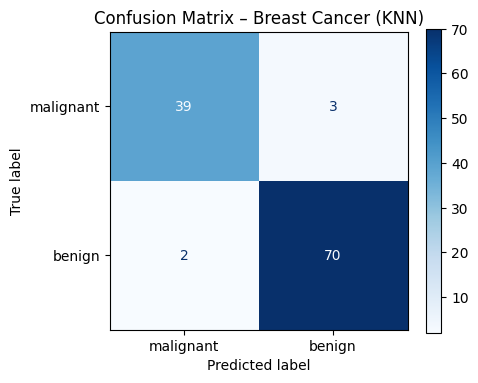

In [3]:
#  — Huấn luyện và đánh giá KNN Classification (Breast Cancer)
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load data
data = load_breast_cancer()
X, y = data.data, data.target
target_names = data.target_names

# Chia train/test và chuẩn hoá (fit scaler trên train, transform test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Huấn luyện KNN
knn = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski')
knn.fit(X_train, y_train)

# Dự đoán & đánh giá
y_pred = knn.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names))

# Confusion matrix (trực quan)
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=target_names, cmap='Blues', ax=ax)
ax.set_title("Confusion Matrix – Breast Cancer (KNN)")
plt.tight_layout(); plt.show()

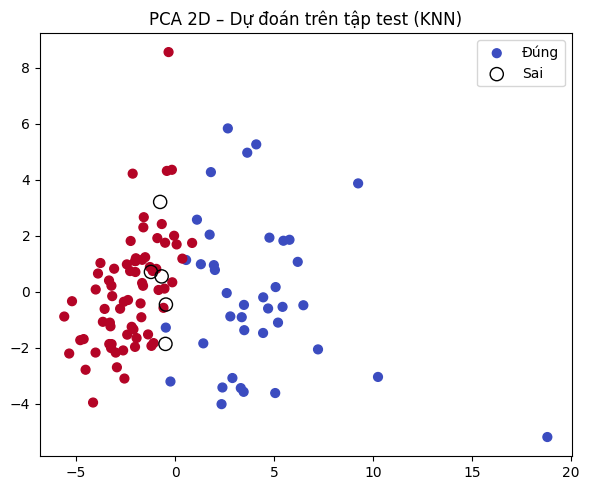

In [4]:
# C — PCA 2D trực quan dự đoán trên tập test, đánh dấu điểm sai
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

mis = (y_pred != y_test)
plt.figure(figsize=(6,5))
plt.scatter(X_test_pca[~mis,0], X_test_pca[~mis,1], c=y_pred[~mis], cmap='coolwarm', s=40, label='Đúng')
plt.scatter(X_test_pca[mis,0], X_test_pca[mis,1], facecolors='none', edgecolors='k', s=90, label='Sai')
plt.title("PCA 2D – Dự đoán trên tập test (KNN)")
plt.legend(); plt.tight_layout(); plt.show()

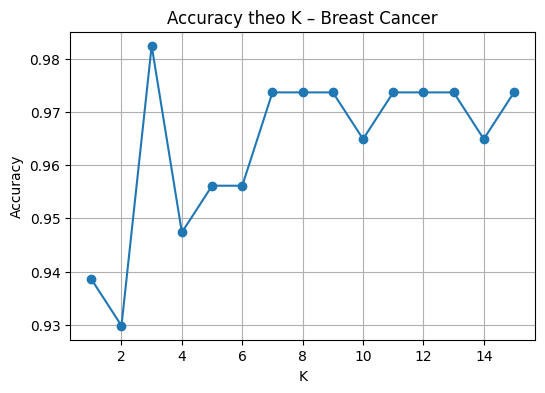

In [5]:
# — Biểu đồ Accuracy theo K
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

ks = list(range(1, 16))
accs = []
for k in ks:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(6,4))
plt.plot(ks, accs, marker='o')
plt.xlabel("K"); plt.ylabel("Accuracy"); plt.title("Accuracy theo K – Breast Cancer")
plt.grid(True); plt.show()

### KNN Regression với Dataset Diabetes
 Mục tiêu
- Dự đoán mức tiến triển bệnh tiểu đường sau 1 năm dựa trên 10 đặc trưng lâm sàng.

 Giới thiệu dataset
- Nguồn: sklearn.datasets.load_diabetes
- Số mẫu: 442
- Số đặc trưng: 10 (tuổi, giới, BMI, huyết áp, sáu chỉ số sinh hóa)
- Biến mục tiêu: target (giá trị liên tục, cao → bệnh nặng hơn)

MSE: 2969.52
R²: 0.440


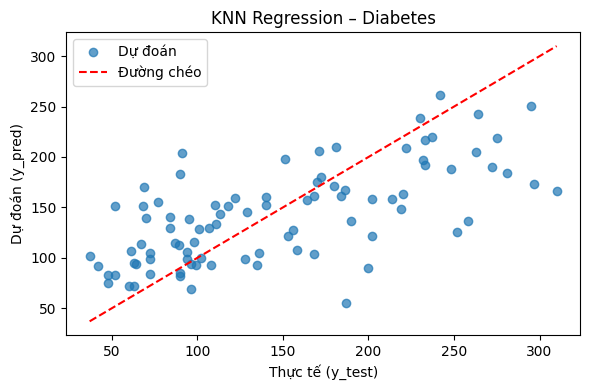

In [7]:
#  — Huấn luyện và đánh giá KNN Regression (Diabetes)
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load data
diab = load_diabetes()
X, y = diab.data, diab.target

# Chia train/test và chuẩn hoá
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN Regression
knn_reg = KNeighborsRegressor(n_neighbors=7)
knn_reg.fit(X_train, y_train)
y_pred = knn_reg.predict(X_test)

# Đánh giá
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.3f}")

# Trực quan: thực tế vs dự đoán
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, c='tab:blue', alpha=0.7, label='Dự đoán')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Đường chéo')
plt.xlabel("Thực tế (y_test)"); plt.ylabel("Dự đoán (y_pred)")
plt.title("KNN Regression – Diabetes")
plt.legend(); plt.tight_layout(); plt.show()

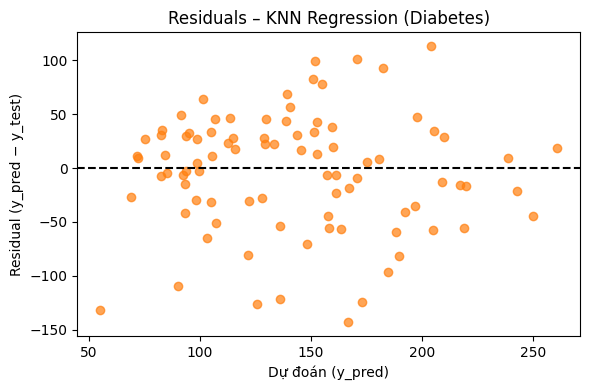

In [8]:
#  — Residuals (phân tích sai lệch)
import matplotlib.pyplot as plt

resid = y_pred - y_test
plt.figure(figsize=(6,4))
plt.scatter(y_pred, resid, c='tab:orange', alpha=0.7)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Dự đoán (y_pred)"); plt.ylabel("Residual (y_pred − y_test)")
plt.title("Residuals – KNN Regression (Diabetes)")
plt.tight_layout(); plt.show()

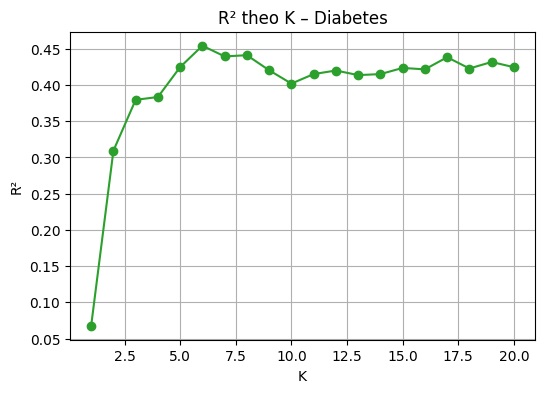

In [9]:
#  — Biểu đồ R² theo K
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

ks = list(range(1, 21))
r2s = []
for k in ks:
    reg = KNeighborsRegressor(n_neighbors=k)
    reg.fit(X_train, y_train)
    r2s.append(r2_score(y_test, reg.predict(X_test)))

plt.figure(figsize=(6,4))
plt.plot(ks, r2s, marker='o', color='tab:green')
plt.xlabel("K"); plt.ylabel("R²")
plt.title("R² theo K – Diabetes")
plt.grid(True); plt.show()

## Kết luận
- KNN đơn giản, trực quan; phù hợp dữ liệu nhỏ/trung bình.
- Luôn chuẩn hoá dữ liệu và chọn `K` bằng cross‑validation.